In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load a sample first — 6 million rows is heavy to explore
df = pd.read_csv('../data/raw/paysim.csv', nrows=500000)
print(df.shape)
print(df.dtypes)
df.head()

(500000, 11)
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
# Column meanings (critical to understand before engineering features):
# step: 1 unit = 1 hour. Total 744 steps = 30 days
# type: transaction type
# amount: transaction amount in local currency
# nameOrig: customer who initiated transaction
# oldbalanceOrg: sender balance BEFORE transaction
# newbalanceOrig: sender balance AFTER transaction
# nameDest: recipient
# oldbalanceDest: recipient balance BEFORE transaction
# newbalanceDest: recipient balance AFTER transaction
# isFraud: 1 = fraudulent (target variable)
# isFlaggedFraud: business rule flag (threshold-based, not ML)

print("Transaction types:")
print(df['type'].value_counts())
print("\nFraud rate overall:")
print(df['isFraud'].value_counts(normalize=True))

Transaction types:
type
CASH_OUT    182316
PAYMENT     164032
CASH_IN     109319
TRANSFER     40730
DEBIT         3603
Name: count, dtype: int64

Fraud rate overall:
isFraud
0    0.999534
1    0.000466
Name: proportion, dtype: float64


In [5]:
# CRITICAL: Fraud ONLY occurs in TRANSFER and CASH_OUT transactions
# This is not a coincidence — it reflects how money laundering works:
# Step 1: TRANSFER money out of victim account
# Step 2: CASH_OUT to extract physical cash

fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'mean'])
fraud_by_type.columns = ['fraud_count', 'fraud_rate']
print(fraud_by_type.sort_values('fraud_count', ascending=False))

          fraud_count  fraud_rate
type                             
CASH_OUT          121    0.000664
TRANSFER          112    0.002750
CASH_IN             0    0.000000
DEBIT               0    0.000000
PAYMENT             0    0.000000


In [3]:
# Fraudulent transactions have a distinctive pattern:
# When fraud occurs, the RECIPIENT balance does NOT increase
# This happens because fraudsters immediately move money onward
# This makes balance discrepancy a powerful fraud signal

fraud_sample = df[df['isFraud'] == 1].head(10)
print("Fraudulent transactions — balance check:")
print(fraud_sample[['amount', 'oldbalanceDest', 'newbalanceDest']].head())

# For legitimate transactions, newbalanceDest should be:
# oldbalanceDest + amount
# For fraud, newbalanceDest is often 0 (money immediately moved out)

Fraudulent transactions — balance check:
      amount  oldbalanceDest  newbalanceDest
2      181.0             0.0             0.0
3      181.0         21182.0             0.0
251   2806.0             0.0             0.0
252   2806.0         26202.0             0.0
680  20128.0             0.0             0.0


Legitimate: 499,767
Fraudulent: 233
Fraud rate: 0.047%


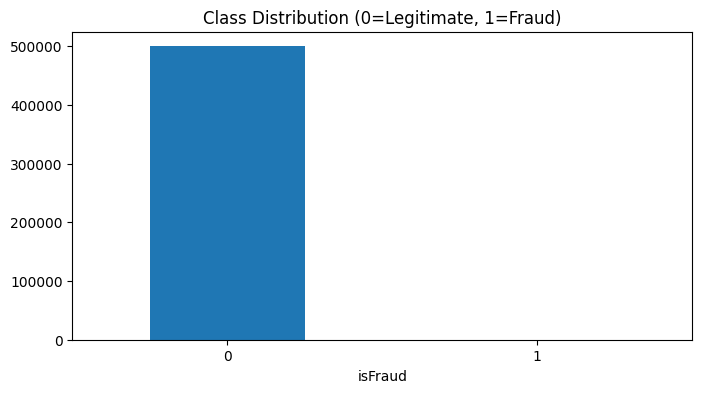

In [5]:
# This is the fundamental challenge of fraud detection
fraud_counts = df['isFraud'].value_counts()
print(f"Legitimate: {fraud_counts[0]:,}")
print(f"Fraudulent: {fraud_counts[1]:,}")
print(f"Fraud rate: {fraud_counts[1]/len(df)*100:.3f}%")

# Visualise
plt.figure(figsize=(8, 4))
fraud_counts.plot(kind='bar')
plt.title('Class Distribution (0=Legitimate, 1=Fraud)')
plt.xticks(rotation=0)
plt.show()

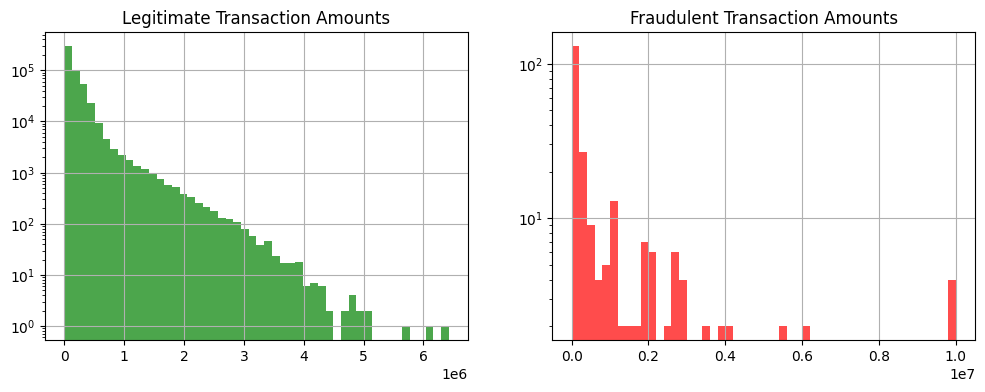

Avg legitimate amount: 166,083
Avg fraudulent amount: 832,901


In [6]:
# Fraudulent transactions tend to be larger
# (fraudsters want maximum extraction)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['isFraud']==0]['amount'].hist(
    bins=50, ax=axes[0], log=True, color='green', alpha=0.7
)
axes[0].set_title('Legitimate Transaction Amounts')

df[df['isFraud']==1]['amount'].hist(
    bins=50, ax=axes[1], log=True, color='red', alpha=0.7
)
axes[1].set_title('Fraudulent Transaction Amounts')
plt.show()

print(f"Avg legitimate amount: {df[df['isFraud']==0]['amount'].mean():,.0f}")
print(f"Avg fraudulent amount: {df[df['isFraud']==1]['amount'].mean():,.0f}")

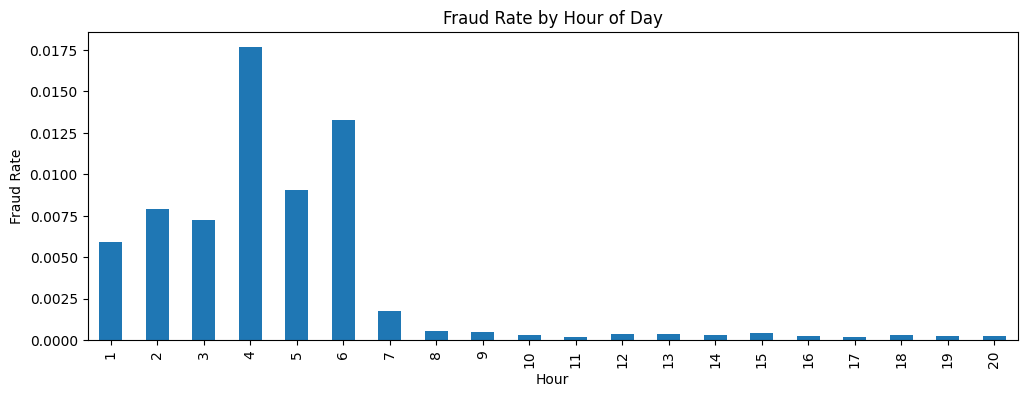

In [7]:
# Fraudsters often operate at specific hours
# step % 24 gives hour of day
df['hour'] = df['step'] % 24

fraud_by_hour = df.groupby('hour')['isFraud'].mean()
plt.figure(figsize=(12, 4))
fraud_by_hour.plot(kind='bar')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.show()

In [8]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'hour'],
      dtype='str')